# Setup libraries 

In [226]:
import Pkg
Pkg.add([
        "CSV",
        "DataFrames",
        "Glob",
        "Makie",
        "CairoMakie",
        "Distributions",
        "HypothesisTests",
        "CategoricalArrays",
        "StatsBase",
        "Printf"
        ])

   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`


In [227]:
import CSV
using Printf
using DataFrames
using CategoricalArrays
using Glob
using Makie, CairoMakie
using Statistics, Distributions, HypothesisTests, StatsBase
using ColorSchemes: tab10
using Colors

In [228]:
lerp(a::Color, b::Color, val::AbstractFloat) = (a .+ (val * (b .- a)))
th = Theme(
    colormap = :tab10,
    palette = Attributes(
        color = tab10,
        patchcolor = map(c -> lerp(RGB(1,1,1), c, 0.8f0), tab10)
    ),
    Axis = (
        colorrange = (1,10),
    ),
    # Hist = (
    #     color = tab10[1],
    # ),
)
set_theme!(merge(th))

# Import data

## Import metadata

In [1039]:
players = CSV.read("clean-data/players.csv", DataFrame)
match_metadata = vcat([CSV.read(f, DataFrame) for f in glob("*matches.csv", "clean-data")]...);

## Merge data from different files

In [943]:
colset = [
    "match_id",
    "ElapsedTime",
    "SetNo",
    # "P1GamesWon",
    # "P2GamesWon",
    "SetWinner",
    "GameNo",
    "GameWinner",
    "PointNumber",
    "PointWinner",
    "PointServer",
    "Speed_KMH",
    "P1Score",
    "P2Score",
    "P1PointsWon",
    "P2PointsWon",
    # "P1Ace",
    # "P2Ace",
    # "P1Winner",
    # "P2Winner",
    # "P1DoubleFault",
    # "P2DoubleFault",
    # "P1UnfErr",
    # "P2UnfErr",
    "P1BreakPoint",
    "P2BreakPoint",
    "P1BreakPointWon",
    "P2BreakPointWon",
    # "P1SecondSrvIn",
    # "P2SecondSrvIn",
    # "P1SecondSrvWon",
    # "P2SecondSrvWon",
    # "P1ForcedError",
    # "P2ForcedError"
];

In [944]:
dfs = Dict(basename(f) => CSV.read(f, DataFrame) for f in glob("*points.csv", "tennis-data"))
tournaments = keys(dfs) |> collect |> sort
sorted_dfs = [dfs[t] for t in tournaments]
common_cols = intersect([names(df) for df in sorted_dfs]...);

In [945]:
all_matches = vcat([select!(df, colset) for df in sorted_dfs]...);

### Add player ids

In [946]:
leftjoin!(all_matches, match_metadata[:,[:match_id, :player1id, :player2id]], on = :match_id);

## Remove entire matches when necessary data are missing

In [947]:
df = all_matches
kept = []
required_cols = [
    :P1BreakPoint,
    :P2BreakPoint,
    :PointWinner,
    :PointNumber,
    :player1id,
    :player2id
]
set_grps = groupby(df, [:match_id])
dfg = [grp for grp in set_grps if !any(ismissing.(Matrix(grp[:, required_cols])))];
df = vcat(dfg...)

println("Removed missing matches: $(length(set_grps) - length(dfg))")

Removed missing matches: 2119


## Add year, tournament, and match number

In [948]:
# add tournament and year columns
function from_matchid(mid)
    (year, tmnt) = match(r"(\d{4})-([a-z]+)", mid)
    year = parse(Int, year)
    permutedims([year, tmnt])
end

yr_tmnt = vcat(from_matchid.(df.match_id)...)
insertcols!(df, 2, :Year => yr_tmnt[:,1], :Tmnt => yr_tmnt[:,2]);

In [949]:
insertcols!(df, 4, :MatchNum => missing)
for gdf in groupby(df, :Year)
    gdf[!,:MatchNum] = groupindices(groupby(gdf, :match_id))
end

## Add server columns

In [950]:
### BreakPoint column

df[:,:BreakPoint] = BitVector((df.P1BreakPoint) .+ (df.P2BreakPoint));

### Tiebreaker column

tb_games_ids = [
    Vector(grp[1, [:match_id, :SetNo, :GameNo]]) for grp in 
        groupby(df, [:match_id, :SetNo, :GameNo]) if
        any(Matrix(grp[:, [:P1Score, :P2Score]] .== "1"))
]
insertcols!(df, :Tiebreaker => zeros(Bool, nrow(df)))
for (id, setno, gameno) in tb_games_ids
    idx = df.match_id .== id .&& df.SetNo .== setno .&& df.GameNo .== gameno
    df[idx, :Tiebreaker] .= 1
end

### ServerWon column

insertcols!(df, :ServerWon => zeros(Bool, nrow(df)))
df[df.PointWinner .== df.PointServer, :ServerWon] .= 1;

### ServerId column

transform!(df, 
    [:PointServer, :player1id, :player2id] => 
    ByRow((s, p1, p2) -> s == 1 ? p1 : p2) =>
    :ServerId
);

all_matches = df;

## Reduce data to certain players and matches after 2022

### Keep only men's singles games

In [951]:
function is_mens_single(event_name)
    if ismissing(event_name)
        return false
    end
    event_name ∈ ["Men's Singles", "event_MS"]
end

is_mens_single (generic function with 1 method)

In [1153]:
select!(players, Not(intersect(names(players), ["is_male", "no_matches"])));
select!(match_metadata, Not(intersect(names(match_metadata), ["player_no", "player_id", "is_male"])));

In [1154]:
df = match_metadata
males = Set(Matrix(df[is_mens_single.(df.event_name), [:player1id, :player2id]]))
males1 = df[df.player1id .∈ Ref(males), :player2id]
males2 = df[df.player2id .∈ Ref(males), :player1id]
union!(males, males1, males2)
df.is_male .= false
df[df.player1id .∈ Ref(males) .|| df.player2id .∈ Ref(males), :is_male] .= true
df[df.is_male, :event_name] .= "event_MS"

players.is_male .= false
players[players.id .∈ Ref(males), :is_male] .= true

match_metadata = df;
mdf = df[df.is_male,:];

### Make sure data set contains $n$ games for 10 most played players

In [1079]:
df = stack(match_metadata, 
    [:player1id, :player2id],
    variable_name = :player_no, 
    value_name = :player_id
)
df = innerjoin(all_matches, select(df, [:match_id, :player_id, :player_no]), on = :match_id);

players.avg_speed_kmh .= 0.0
for g in groupby(df, :player_id)
    g.player_no = 1 .+ (g.player_no .== "player2id")
    speed = mean(g[g.PointServer .== g.player_no .&& g.Speed_KMH .> 0, :Speed_KMH])
    players[players.id .== g.player_id[1], :avg_speed_kmh] .= speed
end 

In [1155]:
df = mdf
df = df[df.year .>= 2020 .&& df.year .<= 2024,:]

valid_match_ids = unique(all_matches[all_matches.Year .>= 2020, :match_id])
df = df[df.match_id .∈ Ref(valid_match_ids),:]

df = vcat(
    transform(insertcols(df, 1, :player_no => 1), :player1id => :player_id),
    transform(insertcols(df, 1, :player_no => 2), :player2id => :player_id)
)
df = combine(
    groupby(df,:player_id),
    :, :player_id => length => :no_matches
)

df = sort(df, :no_matches)

leftjoin!(players, unique(select(df, :no_matches, :player_id)), on = :id => :player_id)
pids = last(sort(dropmissing(players[players.is_male,:], :no_matches), :no_matches)[:, :id], 10)
match_ids = Set()
for pid in pids
    df = all_matches
    mids = df[df.player1id .== pid .|| df.player2id .== pid,:match_id]
    union!(match_ids, sample(mids, 12))
end

df = all_matches[all_matches.match_id .∈ Ref(match_ids),:];

## Save to other dataframe

In [1157]:
data_sub = df;

In [345]:
data_main = df;

## Export data

In [28]:
function write_csv(filename, data; kwargs...)
    bool_cols = names(data, Bool)
    CSV.write(
        filename,
        transform(data, bool_cols .=> ByRow(Int) .=> bool_cols)
    )
end

write_csv (generic function with 1 method)

In [357]:
bool_cols = names(df, Bool)
CSV.write(
    joinpath("clean-data", "master-v1.csv"),
    transform(df, bool_cols .=> ByRow(Int) .=> bool_cols)
)

"clean-data/master-v1.csv"

## Take subset

In [1158]:
# dfg = groupby(df, :match_id)
# dfs = vcat(sample(dfg |> collect, 100)...);
write_csv("clean-data/master-sub.csv", data_sub)

"clean-data/master-sub.csv"

# Analysis

## Initialize dataframe

In [192]:
dbp = df[df.BreakPoint,:]
dbp = dbp[sample(1:nrow(dbp), 1000),:]
dtb = df[df.Tiebreaker,:]
dtb = dtb[sample(1:nrow(dtb), 1000),:]
dany = df[sample(1:nrow(df), 1000),:]
df = vcat(dbp, dtb, dany);

In [1190]:
df = data_sub;

In [265]:
df = data_main[data_main.ServerId .== 1496,:];

## Data characterization

In [1194]:
println(
    "Matches: $(df.match_id |> unique |> length)"
)
println("Points played: $(nrow(df))")
println(
    "Distinct players: $(
        vcat(df.player1id, df.player2id) |> unique |> length
    )"
)

Matches: 104
Points played: 24267
Distinct players: 76


In [1216]:
df2 = df[.! (ismissing.(df.player1id) .|| ismissing.(df.player2id)),:]
plmat = combine(
    groupby(select(df2, [:match_id, :player1id, :player2id]), :match_id),
    [:match_id, :player1id, :player2id] => 
    ((mid, p1, p2) -> hcat(first(mid), first(p1), first(p2))) => 
    [:match_id, :player1id, :player2id]
)

total_matches = vcat(
    select(plmat, :player1id => :id),
    select(plmat, :player2id => :id)
)

player_games = combine(
    groupby(total_matches, :id),
    :id => (ids -> [length(ids), first(ids)]') => [:no_games, :id],
);
sort!(player_games, :no_games, rev=true);
# player_games = sort(player_games |>, by = pg -> pg[2]);

In [1341]:
?cut

search: cut cot Out cat count count! vcat Auto cotd counts coth acot put! cbrt



```
cut(x::AbstractArray, breaks::AbstractVector;
    labels::Union{AbstractVector,Function},
    sigdigits::Integer=3,
    extend::Union{Bool,Missing}=false, allowempty::Bool=false)
```

Cut a numeric array into intervals at values `breaks` and return an ordered `CategoricalArray` indicating the interval into which each entry falls. Intervals are of the form `[lower, upper)` (closed on the left), i.e. the lower bound is included and the upper bound is excluded, except the last interval, which is closed on both ends, i.e. `[lower, upper]`.

If `x` accepts missing values (i.e. `eltype(x) >: Missing`) the returned array will also accept them.

!!! note
    For floating point data, breaks may be rounded to `sigdigits` significant digits when generating interval labels, meaning that they may not reflect exactly the cutpoints used.


# Keyword arguments

  * `extend::Union{Bool, Missing}=false`: when `false`, an error is raised if some values in `x` fall outside of the breaks; when `true`, breaks are automatically added to include all values in `x`; when `missing`, values outside of the breaks generate `missing` entries.
  * `labels::Union{AbstractVector, Function}`: a vector of strings, characters or numbers giving the names to use for the intervals; or a function `f(from, to, i::Integer; leftclosed::Bool, rightclosed::Bool, sigdigits::Integer)` that generates the labels from the left and right interval boundaries and the group index. Defaults to [`CategoricalArrays.default_formatter`](@ref), giving `"[from, to)"` (or `"[from, to]"` for the rightmost interval if `extend == true`).
  * `sigdigits::Integer=3`: the minimum number of significant digits to use in labels. This value is increased automatically if necessary so that rounded breaks are unique. Only used for floating point types and when `labels` is a function, in which case it is passed to it as a keyword argument.
  * `allowempty::Bool=false`: when `false`, an error is raised if some breaks other than the last one appear multiple times, generating empty intervals; when `true`, duplicate breaks are allowed and the intervals they generate are kept as unused levels (but duplicate labels are not allowed).

# Examples

```jldoctest
julia> using CategoricalArrays

julia> cut(-1:0.5:1, [0, 1], extend=true)
5-element CategoricalArray{String,1,UInt32}:
 "[-1, 0)"
 "[-1, 0)"
 "[0, 1]"
 "[0, 1]"
 "[0, 1]" 

julia> cut(-1:0.5:1, 2)
5-element CategoricalArray{String,1,UInt32}:
 "[-1, 0)"
 "[-1, 0)"
 "[0, 1]"
 "[0, 1]"
 "[0, 1]"

julia> cut(-1:0.5:1, 2, labels=["A", "B"])
5-element CategoricalArray{String,1,UInt32}:
 "A"
 "A"
 "B"
 "B"
 "B"

julia> cut(-1:0.5:1, 2, labels=[-0.5, +0.5])
5-element CategoricalArray{Float64,1,UInt32}:
 -0.5
 -0.5
 0.5
 0.5
 0.5

julia> fmt(from, to, i; leftclosed, rightclosed) = "grp $i ($from//$to)"
fmt (generic function with 1 method)

julia> cut(-1:0.5:1, 3, labels=fmt)
5-element CategoricalArray{String,1,UInt32}:
 "grp 1 (-1.0//0.0)"
 "grp 1 (-1.0//0.0)"
 "grp 2 (0.0//0.5)"
 "grp 3 (0.5//1.0)"
 "grp 3 (0.5//1.0)"
```

---

```
cut(x::AbstractArray, ngroups::Integer;
    labels::Union{AbstractVector{<:AbstractString},Function},
    sigdigits::Integer=3,
    allowempty::Bool=false,
    weights::Union{AbstractWeights, Nothing}=nothing)
```

Cut a numeric array into `ngroups` quantiles.

This is equivalent to `cut(x, quantile(x, (0:ngroups)/ngroups))`, but breaks are taken from actual data values instead of estimated quantiles.

If `x` contains `missing` values, they are automatically skipped when computing quantiles.

!!! note
    For floating point data, breaks may be rounded to `sigdigits` significant digits when generating interval labels, meaning that they may not reflect exactly the cutpoints used.


# Keyword arguments

  * `labels::Union{AbstractVector, Function}`: a vector of strings, characters or numbers giving the names to use for the intervals; or a function `f(from, to, i::Integer; leftclosed::Bool, rightclosed::Bool, sigdigits::Integer)` that generates the labels from the left and right interval boundaries and the group index. Defaults to [`CategoricalArrays.default_formatter`](@ref), giving `"[from, to)"` (or `"[from, to]"` for the rightmost interval if `extend == true`) if `allowempty=false`, otherwise to [`CategoricalArrays.numbered_formatter`](@ref), which prefixes the label with the quantile number to ensure uniqueness.
  * `sigdigits::Integer=3`: the minimum number of significant digits to use when rounding breaks for inclusion in generated labels. This value is increased automatically if necessary so that rounded breaks are unique. Only used for floating point types and when `labels` is a function, in which case it is passed to it as a keyword argument.
  * `allowempty::Bool=false`: when `false`, an error is raised if some quantiles breakpoints other than the last one are equal, generating empty intervals; when `true`, duplicate breaks are allowed and the intervals they generate are kept as unused levels (but duplicate labels are not allowed).
  * `weights::Union{AbstractWeights, Nothing}=nothing`: observations weights to used when computing quantiles (see `quantile` documentation in StatsBase).


In [1369]:
bins = [0:2:10...,20]
labels = ["$(b+1)-$(b+2)" for b in bins[1:end-1]]
npg = cut(player_games.no_games, bins, labels = (f, t, i; kwargs...) -> "$f-$t")
npg = vcat([(p[1], p[2]) for p in countmap(npg)]...)

4-element Vector{Tuple{CategoricalValue{String, UInt32}, Int64}}:
 ("10-20", 10)
 ("4-6", 1)
 ("2-4", 10)
 ("0-2", 55)

In [1384]:
lab = String(npg[1][1])

"0-2"

In [1410]:
levels(npg[1][1])[levelcode(npg[1][1])]

CategoricalValue{Int64, UInt32} 1 (2/11)

In [1448]:
vcat([[p[1] p[2]] for p in npg]...)

5×2 Matrix{Int64}:
  1  55
  2   8
  3   2
  4   1
 10  10

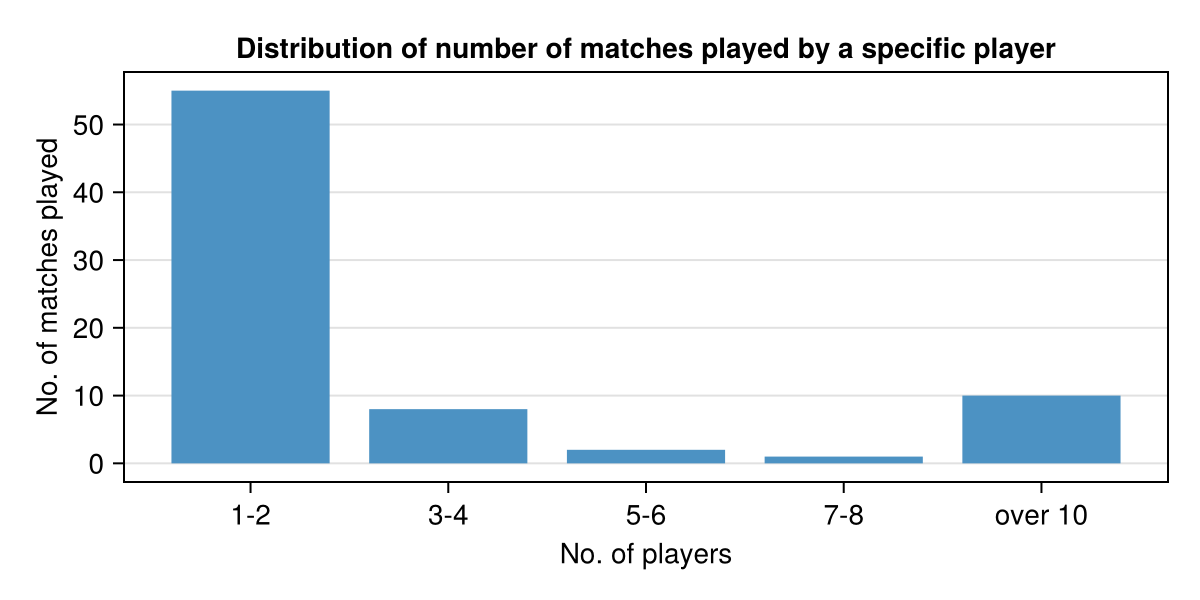

In [1481]:
tmnts = categorical([d.Tmnt[1] for d in groupby(df, :match_id)])
tmnt_counts = countmap(tmnts)

f = Figure(size = (600, 300))

bins = 0:10
labels = ["$(b+1)-$(b+2)" for b in bins[1:end-1]]
npg = cut(player_games.no_games, bins, extend = true, labels = (f,t,i;kw...) -> f)
npg = vcat([[p[1] p[2]] for p in countmap(npg)]...)
npg = npg[sortperm(npg[:,1]),:]

labels = [
    begin
        if lb >= 10
            "over 10"
        else   
            m = 2 * lb - 1
            M = 2 * lb
            "$m-$M"
        end
    end for lb in npg[:,1]
]

ax2 = Axis(f[1,1],
    title = "Distribution of number of matches played by a specific player",
    xlabel = "No. of players",
    ylabel = "No. of matches played",
    xgridvisible = false,
    # xticksvisible = false,
    # xticklabelsvisible = false,
    xticks = (1:size(npg,1), labels),
    yticks = 0:10:60,
)


plt = barplot!(npg[:,2])

f

In [1439]:
CairoMakie.save(joinpath("figs", "player_freq.png"), f)

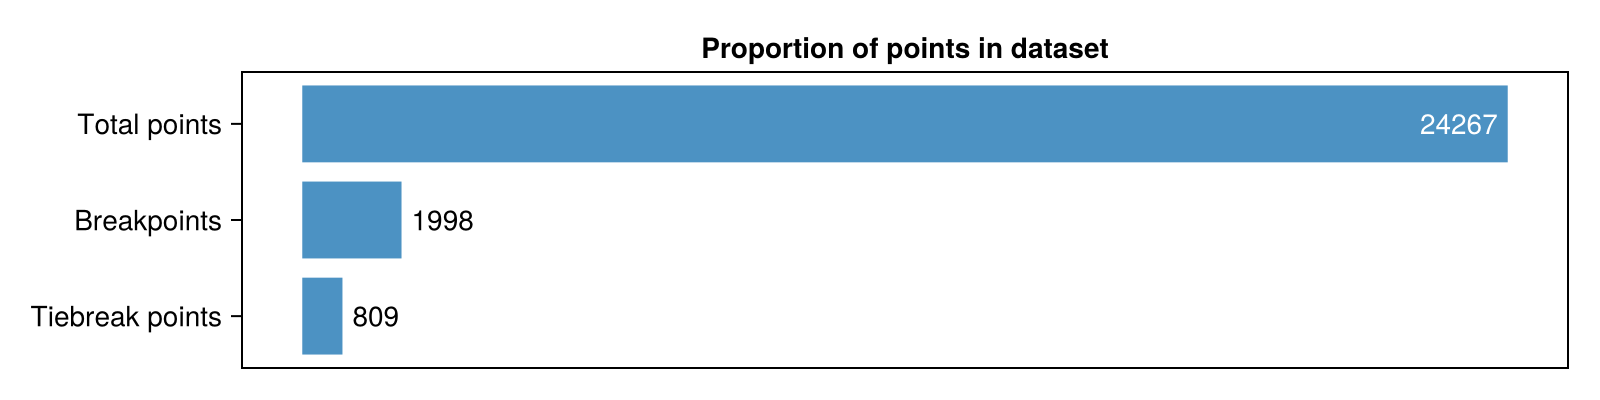

In [1444]:
n_games = nrow(df)
n_bp = nrow(df[df.BreakPoint,:])
n_tb = nrow(df[df.Tiebreaker,:])
bars = [n_games, n_bp, n_tb]
# labels = [
#     replace(
#         @sprintf("%.2e (%.2d%%)", b, round(100 * b/n_games, sigdigits=2)),
#         r"e\+0" => "e"
#     ) for b in bars
# ]

plt = barplot(
    [3,2,1],
    bars,
    axis = (
        title = "Proportion of points in dataset",
        yticks = (1:3, ["Tiebreak points", "Breakpoints", "Total points"]),
        xticksvisible = false,
        xticklabelsvisible = false,
        xgridvisible = false,
        ygridvisible = false,
    ),
    bar_labels = string.(bars),
    direction = :x,
    figure = (
        size = (800, 200),
    ),
    color_over_bar = :white,
    flip_labels_at = 0.85 * n_games,
)

In [1445]:
CairoMakie.save(joinpath("figs", "pointprops.png"), plt)

## Histogram of win probabilities

In [1427]:
gdf = groupby(df, [:match_id]);

In [1428]:
pws = zeros(length(gdf))
bpws = zeros(Union{Float64, Missing}, length(gdf))
for (i,g) in enumerate(gdf)
    gbp = g[g.BreakPoint,:]
    bpsw = mean(gbp.ServerWon)
    
    pwi = g.PointWinner .!= 0
    gpw = g[pwi,:]
    spw = mean(gpw.ServerWon)
    pws[i] = spw
    bpws[i] = bpsw
end
filter!((!) ∘ isnan, pws);
filter!((!) ∘ isnan, bpws);
# filter!((!) ∘ iszero, bps);

In [1429]:
println("Server wins:")
println("Mean: $(mean(pws))")
println("SD: $(std(pws))\n")

println("Breakpoint server wins:")
println("Mean: $(mean(bpws))")
println("SD: $(std(bpws))")

Server wins:
Mean: 0.6365217998862656
SD: 0.0424496125587965

Breakpoint server wins:
Mean: 0.5887515621359138
SD: 0.13609172380633117


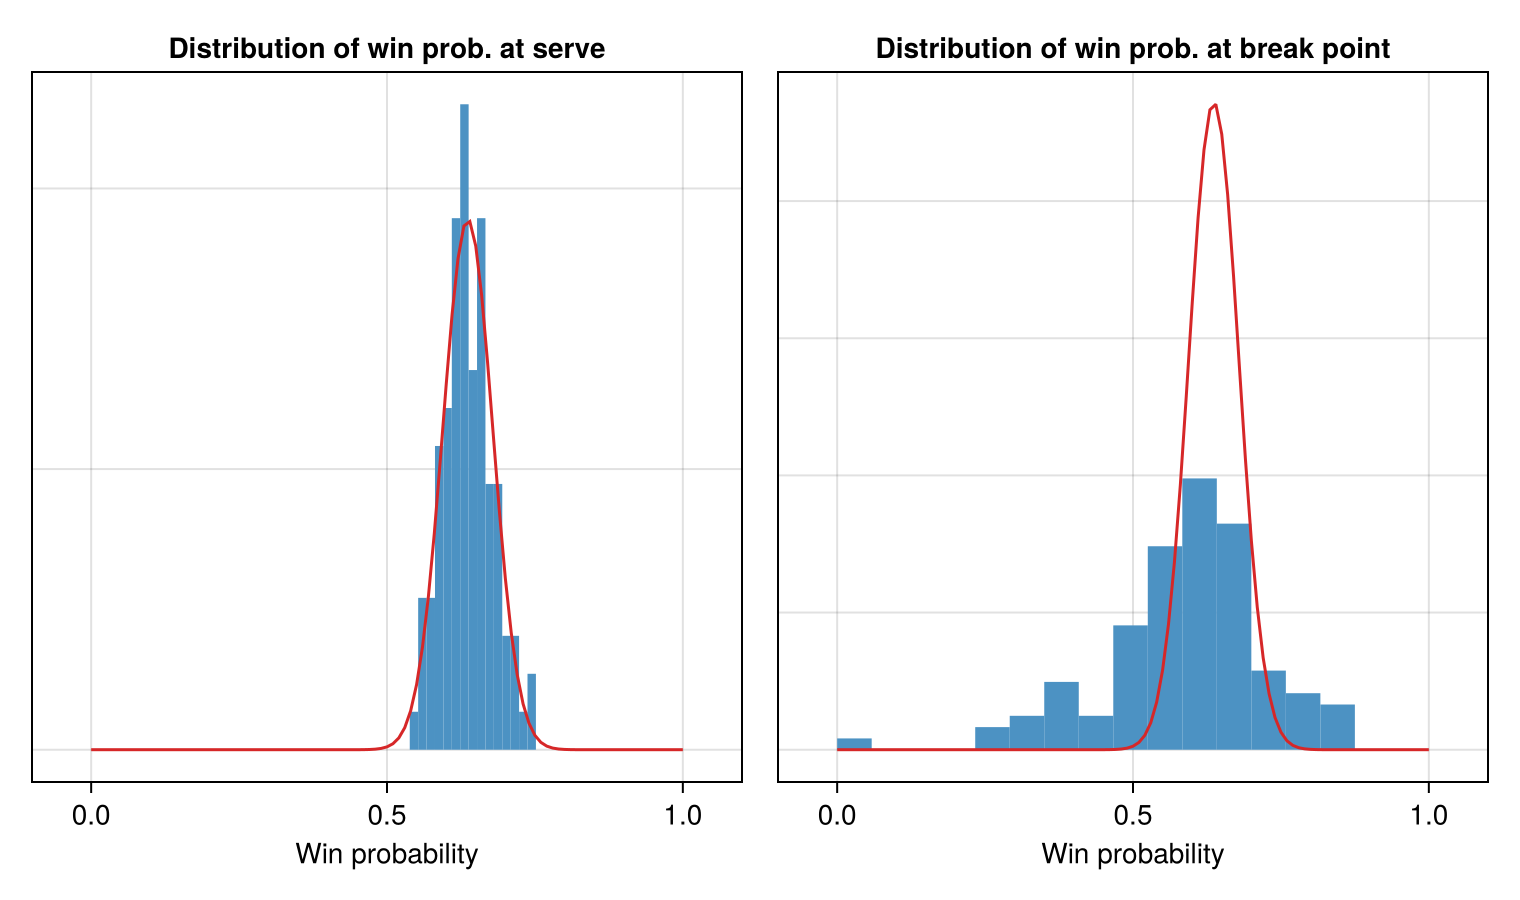

In [1430]:
mkax(f; kwargs...) = Axis(f,
    limits = ((-0.1,1.1), nothing);
    aspect = 1,
    xlabel = "Win probability",
    yticksvisible = false,
    yticklabelsvisible = false,
    kwargs...
)
f = Figure()
mkax(f[1,1], title = "Distribution of win prob. at serve")
hist!(pws, normalization = :pdf)
x = 0:0.01:1
y_pws = pdf(fit(Normal, pws), x)
lines!(x,y_pws, color = tab10[4])

mkax(f[1,2], title = "Distribution of win prob. at break point")
hist!(bpws, normalization = :pdf)
lines!(x,y_pws, color = tab10[4])

for c in 1:2
    colsize!(f.layout, c, Aspect(1,1.0))
end
resize_to_layout!(f)

f

In [1431]:
mean(bpws)

0.5887515621359138

In [1432]:
CairoMakie.save("figs/win_prob_hists.png", f)

In [1433]:
pws = zeros(length(gdf))
tbws = zeros(length(gdf))
for (i,g) in enumerate(gdf)
    gtb = g[g.Tiebreaker,:]
    tbsw = mean(gtb.ServerWon)
    
    pwi = g.PointWinner .!= 0
    gpw = g[pwi,:]
    spw = mean(gpw.ServerWon)
    pws[i] = spw
    tbws[i] = tbsw
end
filter!((!) ∘ isnan, pws);
filter!((!) ∘ isnan, tbws);

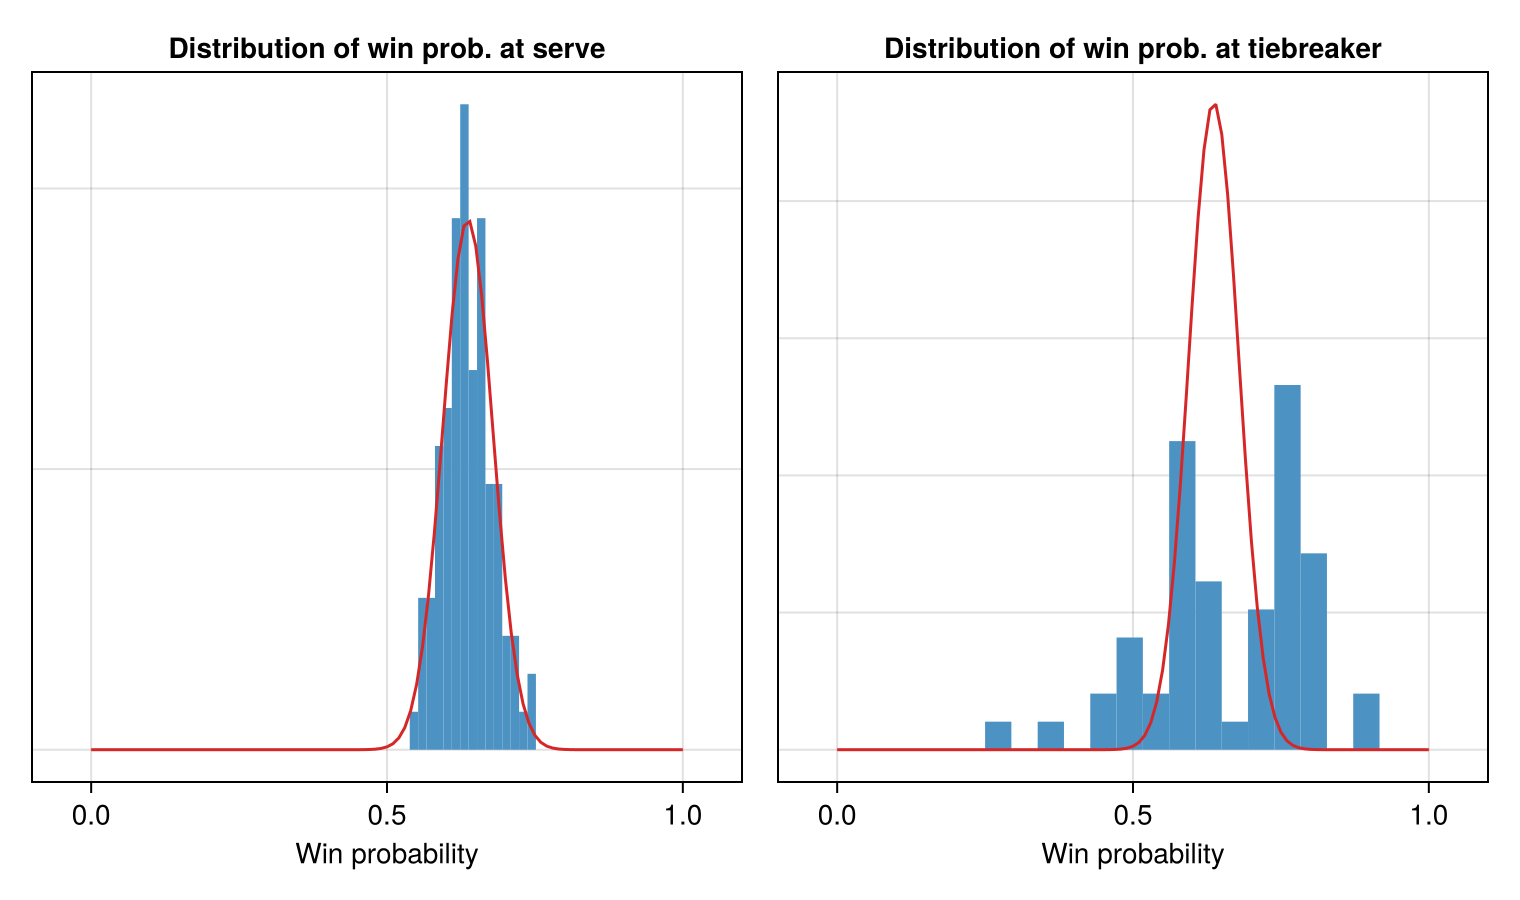

In [1434]:
mkax(f; kwargs...) = Axis(f,
    limits = ((-0.1,1.1), nothing);
    aspect = 1,
    xlabel = "Win probability",
    yticksvisible = false,
    yticklabelsvisible = false,
    kwargs...
)
f = Figure()
mkax(f[1,1], title = "Distribution of win prob. at serve")
hist!(pws, normalization = :pdf)
x = 0:0.01:1
y_pws = pdf(fit(Normal, pws), x)
lines!(x,y_pws, color = tab10[4])

mkax(f[1,2], title = "Distribution of win prob. at tiebreaker")
hist!(tbws, normalization = :pdf)
lines!(x,y_pws, color = tab10[4])

for c in 1:2
    colsize!(f.layout, c, Aspect(1,1.0))
end
resize_to_layout!(f)

f

In [1435]:
CairoMakie.save("figs/win_prob_tb_hists.png", f)

### Goodness of fit test 

We test the probability that the break point serve win probability distribution is the same as the estimated normal distribution of the win serve win probability. We use the fact that, for $X_i \sim N(0,1)$,
$$
\sum_i^n (X_i - \bar{X})^2 \sim \chi_{n-1}^2 \quad \text{where}\quad 
\bar{X} = \frac{1}{n} \sum_i^n X_i.
$$

In [171]:
d = fit(Normal, pws)
T = sum((tbws .- mean(d)).^2) / var(d)
p_pws = 1 - cdf(Chisq(length(tbws)-1), T)

0.0

Then we also do a Kolmogorov-Smirnov test.

In [170]:
pvalue(ApproximateTwoSampleKSTest(pws, skipmissing(bpws) |> collect))

3.452935708006813e-17